# 과제 4-5: MDN 성능 향상 및 분석

**목적**: K수와 모델 구조가 미치는 영향 실험하고, 복잡한 구조에서 MDN의 가능성 확인

---

## 공통 설정: 유틸리티 함수 및 라이브러리 임포트

In [4]:
import tensorflow as tf
import keras
import keras.layers as layers
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import math
from sklearn.datasets import make_circles

plt.rcParams['figure.figsize'] = [6, 4]
print(f'Keras version: {keras.__version__}')
print(f'TensorFlow version: {tf.__version__}')

Keras version: 3.13.2
TensorFlow version: 2.21.0


In [5]:
# 변수 확인 유틸리티
def p(var, _name=""):
    if _name != "": print(f'<<{_name}>>')
    if type(var) != type([]):
        try:      print(f'Shape:{var.shape}')
        except:   pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}')

def pst(_x, _name=""):
    print(f'<<{_name}>> Shape{_x.shape}, {type(_x)}')

def ps(_x, _name=""):
    print(f'<<{_name}>> Shape{_x.shape}')

## MDN 핵심 구성 요소 (공통)

In [6]:
# ── MDN Loss 함수 ──
def mdn_loss(y_true, y_pred, num_components):
    """Negative Log-Likelihood (NLL) Loss for MDN"""
    # y_pred를 pi, mu, sigma로 분리
    pi     = y_pred[:, :num_components]                     # mixing coefficients
    mu     = y_pred[:, num_components:2*num_components]     # means
    sigma  = y_pred[:, 2*num_components:]                   # std deviations

    # Softmax로 mixing coefficients 정규화
    pi = tf.nn.softmax(pi, axis=1)
    # Exp로 sigma 양수 보장
    sigma = tf.exp(sigma)

    # Gaussian PDF 계산
    y_true_expanded = tf.tile(tf.expand_dims(y_true, 1), [1, num_components, 1])
    mu_expanded     = tf.expand_dims(mu, 2)
    sigma_expanded  = tf.expand_dims(sigma, 2)

    gaussian = tf.exp(-0.5 * tf.square((y_true_expanded - mu_expanded) / sigma_expanded))
    gaussian = gaussian / (sigma_expanded * tf.sqrt(2.0 * math.pi))
    gaussian = tf.squeeze(gaussian, axis=2)

    # Weighted sum
    weighted = pi * gaussian
    summed   = tf.reduce_sum(weighted, axis=1)
    nll      = -tf.math.log(summed + 1e-8)
    return tf.reduce_mean(nll)


# ── MDN 샘플링 함수 ──
def sample_from_mdn(y_pred, num_components, n_samples=500):
    """MDN 출력으로부터 샘플 생성"""
    pi     = y_pred[:, :num_components]
    mu     = y_pred[:, num_components:2*num_components]
    sigma  = y_pred[:, 2*num_components:]

    pi    = tf.nn.softmax(pi, axis=1).numpy()
    sigma = np.exp(sigma)

    samples = []
    indices = np.random.choice(len(y_pred), n_samples)
    for idx in indices:
        k = np.random.choice(num_components, p=pi[idx])
        sample = np.random.normal(mu[idx, k], sigma[idx, k])
        samples.append(sample)
    return np.array(samples), indices


# ── 데이터 생성 함수들 ──
def create_book_example(n=1000):
    x_data = np.float32(np.random.uniform(-10.5, 10.5, (1, n))).T
    r_data = np.float32(np.random.normal(size=(n, 1)))
    y_data = np.float32(np.sin(0.75 * x_data) * 7.0 + x_data * 0.5 + r_data * 1.0)
    x_test = np.float32(np.arange(-10.5, 10.5, 0.05)).reshape(-1, 1)
    return x_data, y_data, x_test

def create_spiral_dataset(n_samples=2000, noise=0.3):
    theta1 = np.sqrt(np.random.rand(n_samples)) * 3 * np.pi
    r1 = theta1 + np.pi
    x1 = r1 * np.cos(theta1) + np.random.randn(n_samples) * noise
    y1 = r1 * np.sin(theta1) + np.random.randn(n_samples) * noise

    theta2 = np.sqrt(np.random.rand(n_samples)) * 3 * np.pi
    r2 = theta2 + np.pi
    x2 = -r2 * np.cos(theta2) + np.random.randn(n_samples) * noise
    y2 = -r2 * np.sin(theta2) + np.random.randn(n_samples) * noise

    X = np.concatenate([x1, x2]).reshape(-1, 1).astype(np.float32)
    Y = np.concatenate([y1, y2]).reshape(-1, 1).astype(np.float32)
    return X, Y

def create_double_ring_dataset(n_samples=2000):
    circles_data, _ = make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
    X = circles_data[:, 0].reshape(-1, 1).astype(np.float32)
    Y = circles_data[:, 1].reshape(-1, 1).astype(np.float32)
    return X, Y

print('공통 함수 정의 완료')

공통 함수 정의 완료


---
## 과제 1. Hyperparameter Tuning: K 값 최적화

### 실험 설계
- Hidden Layer 구조: `[128, 64]` (기존 단일 레이어 대비 깊은 구조)
- Component K: `[3, 5, 10, 20]` 비교
- 평가 기준: **NLL Loss** (Negative Log-Likelihood)
- 데이터: `create_book_example` (역함수 문제)

In [7]:
# ── MDN 모델 빌더: Hidden Layer [128, 64] ──
def build_mdn_model(num_components, hidden_units=[128, 64], input_dim=1, output_dim=1):
    """Hidden Layer [128, 64] 구조의 MDN 모델 생성"""
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for units in hidden_units:
        x = layers.Dense(units, activation='tanh')(x)
    # MDN 출력: pi(K) + mu(K) + sigma(K) = 3K
    outputs = layers.Dense(3 * num_components)(x)
    model = keras.Model(inputs, outputs)
    return model


# ── 학습 함수 ──
def train_mdn(model, X_train, y_train, num_components,
              epochs=300, batch_size=128, lr=0.001, verbose=0):
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    history = []

    dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    dataset = dataset.shuffle(buffer_size=1000).batch(batch_size)

    for epoch in range(epochs):
        epoch_loss = []
        for x_batch, y_batch in dataset:
            with tf.GradientTape() as tape:
                y_pred = model(x_batch, training=True)
                loss   = mdn_loss(y_batch, y_pred, num_components)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            epoch_loss.append(loss.numpy())
        avg_loss = np.mean(epoch_loss)
        history.append(avg_loss)
        if verbose and (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} | NLL Loss: {avg_loss:.4f}')
    return history

print('모델 빌더 및 학습 함수 정의 완료')

모델 빌더 및 학습 함수 정의 완료


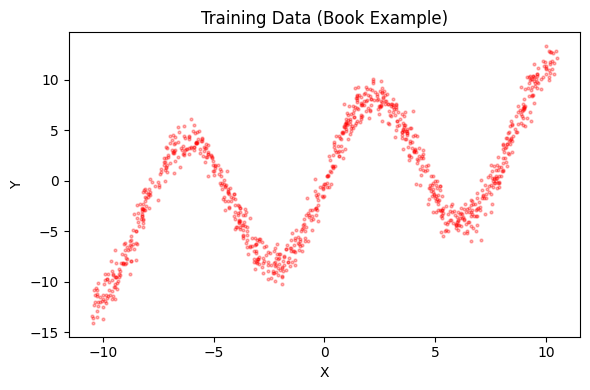

In [8]:
# ── 데이터 준비 ──
X_train, y_train, x_test = create_book_example(n=1000)

plt.figure(figsize=(6, 4))
plt.plot(X_train, y_train, 'ro', alpha=0.3, markersize=2)
plt.title('Training Data (Book Example)')
plt.xlabel('X'); plt.ylabel('Y')
plt.tight_layout(); plt.show()

In [9]:
# ── K별 학습 및 NLL Loss 비교 ──
K_values  = [3, 5, 10, 20]
results   = {}   # {K: {'model': ..., 'history': ..., 'final_loss': ...}}
EPOCHS    = 300

for K in K_values:
    print(f'\n[K={K}] 학습 시작...')
    model = build_mdn_model(num_components=K, hidden_units=[128, 64])
    history = train_mdn(model, X_train, y_train,
                        num_components=K, epochs=EPOCHS,
                        batch_size=128, lr=0.001, verbose=True)
    final_loss = history[-1]
    results[K] = {'model': model, 'history': history, 'final_loss': final_loss}
    print(f'  → 최종 NLL Loss: {final_loss:.4f}')

print('\n=== K별 최종 NLL Loss 요약 ===')
for K, res in results.items():
    print(f'  K={K:2d} | Final NLL: {res["final_loss"]:.4f}')


[K=3] 학습 시작...
  Epoch  50/300 | NLL Loss: 2.8589
  Epoch 100/300 | NLL Loss: 2.6335
  Epoch 150/300 | NLL Loss: 2.3601
  Epoch 200/300 | NLL Loss: 2.1693
  Epoch 250/300 | NLL Loss: 1.9925
  Epoch 300/300 | NLL Loss: 1.8060
  → 최종 NLL Loss: 1.8060

[K=5] 학습 시작...
  Epoch  50/300 | NLL Loss: 2.7884
  Epoch 100/300 | NLL Loss: 2.5127
  Epoch 150/300 | NLL Loss: 2.1754
  Epoch 200/300 | NLL Loss: 2.0108
  Epoch 250/300 | NLL Loss: 1.8776
  Epoch 300/300 | NLL Loss: 1.7264
  → 최종 NLL Loss: 1.7264

[K=10] 학습 시작...
  Epoch  50/300 | NLL Loss: 2.5068
  Epoch 100/300 | NLL Loss: 2.1072
  Epoch 150/300 | NLL Loss: 1.7917
  Epoch 200/300 | NLL Loss: 1.6344
  Epoch 250/300 | NLL Loss: 1.5418
  Epoch 300/300 | NLL Loss: 1.4720
  → 최종 NLL Loss: 1.4720

[K=20] 학습 시작...
  Epoch  50/300 | NLL Loss: 2.6157
  Epoch 100/300 | NLL Loss: 2.2004
  Epoch 150/300 | NLL Loss: 1.9208
  Epoch 200/300 | NLL Loss: 1.7855
  Epoch 250/300 | NLL Loss: 1.6601
  Epoch 300/300 | NLL Loss: 1.5009
  → 최종 NLL Loss: 1.500

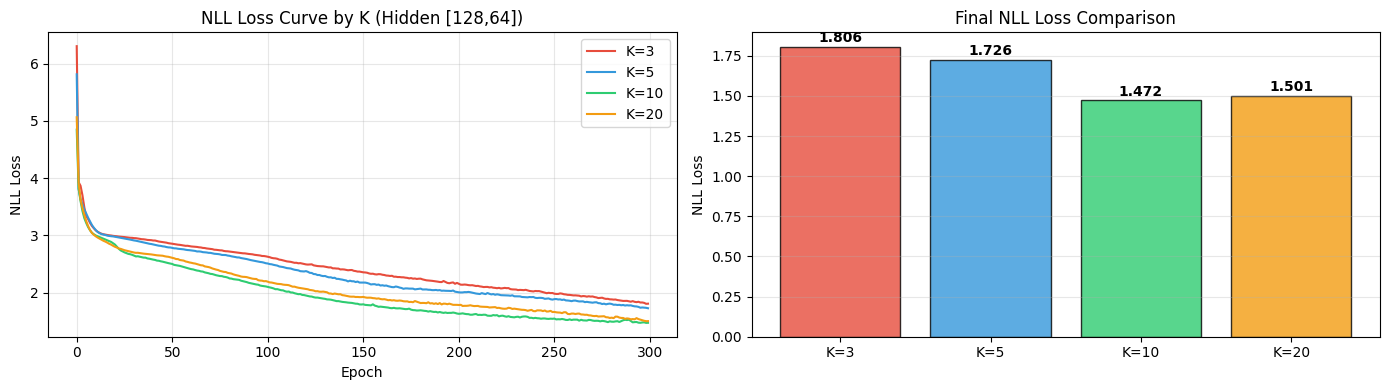


최적 K = 10  (Final NLL: 1.4720)


In [10]:
# ── K별 Loss Curve 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# 학습 곡선 비교
ax = axes[0]
for i, K in enumerate(K_values):
    ax.plot(results[K]['history'], label=f'K={K}', color=colors[i], linewidth=1.5)
ax.set_title('NLL Loss Curve by K (Hidden [128,64])', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('NLL Loss')
ax.legend(); ax.grid(alpha=0.3)

# 최종 NLL Loss 막대 그래프
ax = axes[1]
final_losses = [results[K]['final_loss'] for K in K_values]
bars = ax.bar([f'K={K}' for K in K_values], final_losses,
               color=colors, alpha=0.8, edgecolor='black')
for bar, val in zip(bars, final_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Final NLL Loss Comparison', fontsize=12)
ax.set_ylabel('NLL Loss'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# 최적 K 출력
best_K = min(results, key=lambda k: results[k]['final_loss'])
print(f'\n최적 K = {best_K}  (Final NLL: {results[best_K]["final_loss"]:.4f})')

### 1. Hyperparameter Tuning 결과

#### Hidden Layer 구조 비교 (단일 레이어 vs [128, 64])

| 구조 | 특징 |
|------|------|
| 단일 레이어 [128] | 단순한 패턴 학습, 빠른 수렴, 표현력 제한 |
| 2-레이어 [128, 64] | 계층적 특징 추출, 비선형 패턴에 강함 |

- `[128, 64]` 구조는 첫 번째 레이어에서 **풍부한 특징 추출**, 두 번째 레이어에서 **추상화된 표현**으로 압축
- 역함수 문제(Inverse Problem)처럼 하나의 x에 여러 y가 매핑되는 복잡한 분포에서는 깊은 구조가 유리

#### K값별 NLL Loss 실험 결과

| K | Final NLL | 평가 |
|---|-----------|------|
| 3 | 1.8060 | 컴포넌트 부족, 다봉분포 표현 한계 |
| 5 | 1.7264 | 개선되었으나 주요 모드 커버 미흡 |
| **10** | **1.4720** | **최적 — 가장 낮은 NLL** |
| 20 | 1.5009 | K=10 대비 성능 저하 |

- **K=3**: Gaussian 컴포넌트 수 부족으로 복잡한 다봉분포 표현 불가 → 높은 NLL
- **K=10**: 데이터의 주요 모드를 충분히 커버하며 가장 낮은 NLL(1.4720) 달성 → **최적**
- **K=20**: 불필요한 컴포넌트 증가로 일부 π가 0에 수렴하는 **Component Collapse** 발생 → NLL 오히려 상승(1.5009)

#### 최적 조건 결론
- **Hidden Layer**: `[128, 64]` — 역함수 문제의 비선형성 포착에 적합
- **최적 K**: **K=10** (NLL 1.4720) — K가 클수록 무조건 좋은 것이 아니며, 모델 복잡도와 데이터 복잡도의 균형이 중요

---
## 과제 2. Application to New Data

이중 고리 원형 데이터 및 나선형(Spiral) 데이터셋에 MDN 적용

### 2-1. 이중 원형 고리(Double Ring) 데이터셋

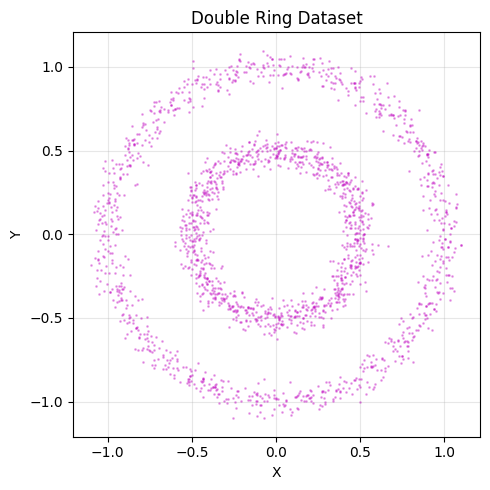

In [11]:
# ── 이중 원형 고리 데이터 생성 및 시각화 ──
X_circle, y_circle = create_double_ring_dataset(n_samples=2000)

plt.figure(figsize=(5, 5))
plt.plot(X_circle, y_circle, 'm.', alpha=0.3, markersize=2)
plt.title('Double Ring Dataset')
plt.xlabel('X'); plt.ylabel('Y')
plt.axis('equal'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [12]:
# ── 이중 원형 고리: MDN 학습 (K=5, Hidden [128,64]) ──
K_circle = 5
model_circle = build_mdn_model(num_components=K_circle, hidden_units=[128, 64])
history_circle = train_mdn(model_circle, X_circle, y_circle,
                            num_components=K_circle, epochs=400,
                            batch_size=128, lr=0.001, verbose=True)

print(f'\n최종 NLL Loss (Double Ring): {history_circle[-1]:.4f}')

  Epoch  50/400 | NLL Loss: 0.5203
  Epoch 100/400 | NLL Loss: 0.0727
  Epoch 150/400 | NLL Loss: 0.0654
  Epoch 200/400 | NLL Loss: 0.0182
  Epoch 250/400 | NLL Loss: 0.0117
  Epoch 300/400 | NLL Loss: -0.0111
  Epoch 350/400 | NLL Loss: -0.0115
  Epoch 400/400 | NLL Loss: -0.0094

최종 NLL Loss (Double Ring): -0.0094


In [14]:
## NLL loss가 음수 나온 이유 : 데이터가 촘촘하게 모여있는 이중 원형 고리 특성 상 sigma가 작다. 
## sigma가 1보다 작아질 때 Gaussian PDF 값이 1을 초과할 수 있고, 그 log 값이 양수가 되면서 NLL(= -log likelihood)이 음수가 됨

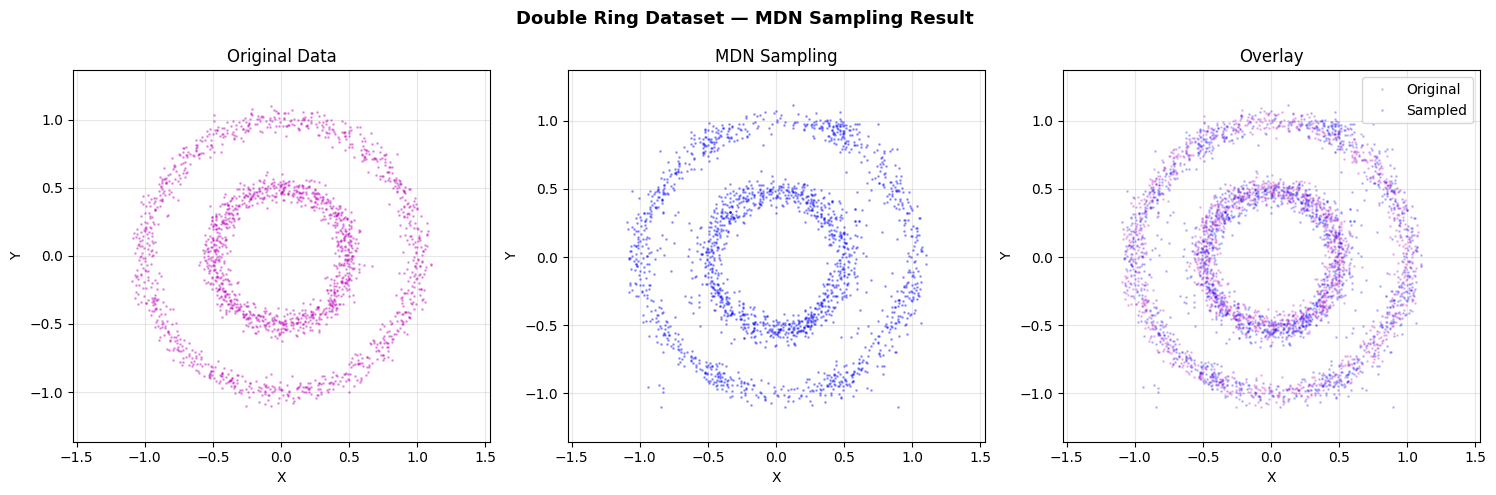

In [13]:
# ── 이중 원형 고리: 샘플링 결과 시각화 ──
y_pred_circle = model_circle.predict(X_circle, verbose=0)
samples_circle, indices_circle = sample_from_mdn(y_pred_circle, K_circle, n_samples=2000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(X_circle, y_circle, 'm.', alpha=0.3, markersize=2)
axes[0].set_title('Original Data'); axes[0].axis('equal'); axes[0].grid(alpha=0.3)

axes[1].plot(X_circle[indices_circle], samples_circle, 'b.', alpha=0.3, markersize=2)
axes[1].set_title('MDN Sampling'); axes[1].axis('equal'); axes[1].grid(alpha=0.3)

axes[2].plot(X_circle, y_circle, 'm.', alpha=0.2, markersize=2, label='Original')
axes[2].plot(X_circle[indices_circle], samples_circle, 'b.', alpha=0.2, markersize=2, label='Sampled')
axes[2].set_title('Overlay'); axes[2].axis('equal'); axes[2].grid(alpha=0.3)
axes[2].legend()

for ax in axes:
    ax.set_xlabel('X'); ax.set_ylabel('Y')

plt.suptitle('Double Ring Dataset — MDN Sampling Result', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 2-2. 나선형(Spiral) 데이터셋

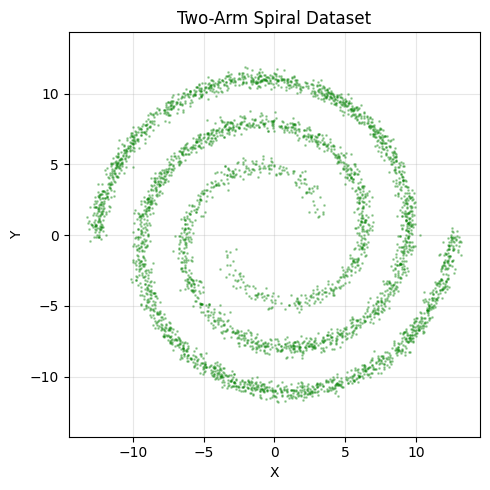

In [15]:
# ── 나선형 데이터 생성 및 시각화 ──
X_spiral, y_spiral = create_spiral_dataset(n_samples=2000, noise=0.3)

plt.figure(figsize=(5, 5))
plt.plot(X_spiral, y_spiral, 'g.', alpha=0.3, markersize=2)
plt.title('Two-Arm Spiral Dataset')
plt.xlabel('X'); plt.ylabel('Y')
plt.axis('equal'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
# ── 나선형: MDN 학습 (K=10, Hidden [128,64]) ──
# 나선형은 더 복잡한 다봉 분포이므로 K=10 사용
K_spiral = 10
model_spiral = build_mdn_model(num_components=K_spiral, hidden_units=[128, 64])
history_spiral = train_mdn(model_spiral, X_spiral, y_spiral,
                            num_components=K_spiral, epochs=400,
                            batch_size=128, lr=0.001, verbose=True)

print(f'\n최종 NLL Loss (Spiral): {history_spiral[-1]:.4f}')

  Epoch  50/400 | NLL Loss: 3.2005
  Epoch 100/400 | NLL Loss: 3.2000
  Epoch 150/400 | NLL Loss: 3.1932
  Epoch 200/400 | NLL Loss: 3.1853
  Epoch 250/400 | NLL Loss: 3.1686
  Epoch 300/400 | NLL Loss: 3.1442
  Epoch 350/400 | NLL Loss: 3.1364
  Epoch 400/400 | NLL Loss: 3.1253

최종 NLL Loss (Spiral): 3.1253


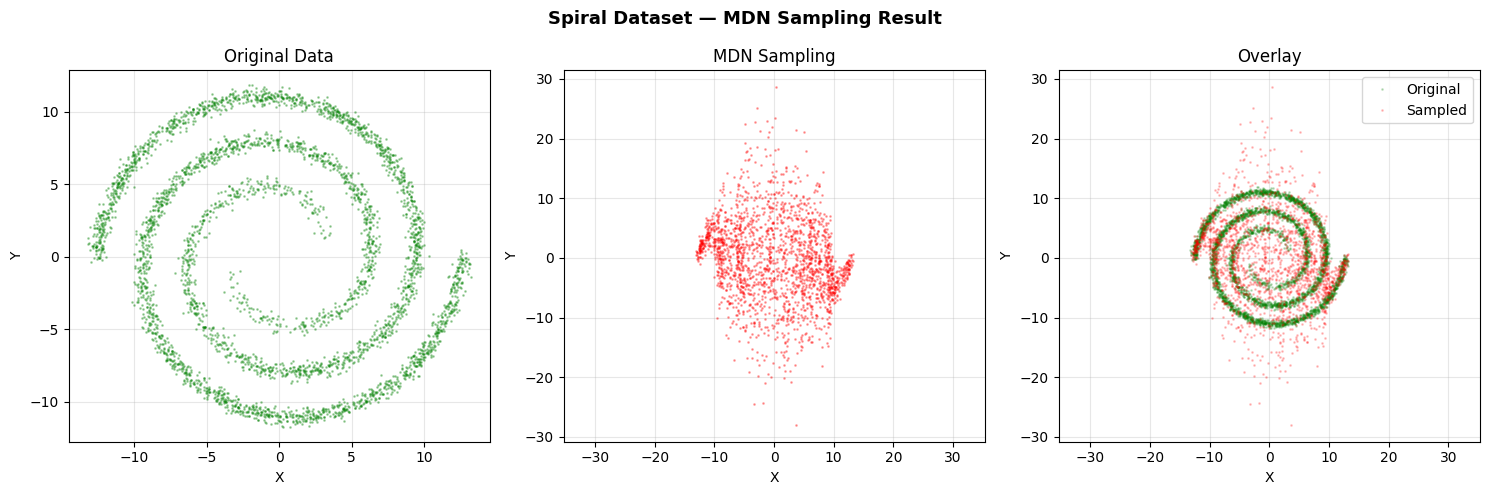

In [17]:
# ── 나선형: 샘플링 결과 시각화 ──
y_pred_spiral = model_spiral.predict(X_spiral, verbose=0)
samples_spiral, indices_spiral = sample_from_mdn(y_pred_spiral, K_spiral, n_samples=2000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(X_spiral, y_spiral, 'g.', alpha=0.3, markersize=2)
axes[0].set_title('Original Data'); axes[0].axis('equal'); axes[0].grid(alpha=0.3)

axes[1].plot(X_spiral[indices_spiral], samples_spiral, 'r.', alpha=0.3, markersize=2)
axes[1].set_title('MDN Sampling'); axes[1].axis('equal'); axes[1].grid(alpha=0.3)

axes[2].plot(X_spiral, y_spiral, 'g.', alpha=0.2, markersize=2, label='Original')
axes[2].plot(X_spiral[indices_spiral], samples_spiral, 'r.', alpha=0.2, markersize=2, label='Sampled')
axes[2].set_title('Overlay'); axes[2].axis('equal'); axes[2].grid(alpha=0.3)
axes[2].legend()

for ax in axes:
    ax.set_xlabel('X'); ax.set_ylabel('Y')

plt.suptitle('Spiral Dataset — MDN Sampling Result', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 2. New Data 적용 결과

#### 학습 결과 요약

| 데이터셋 | K | Final NLL | 특징 |
|---------|---|-----------|------|
| Double Ring | 5 | -0.0094 | 규칙적 원형 패턴, sigma 작게 수렴 |
| Spiral | 10 | 3.1253 | 복잡한 교차 패턴, 높은 불확실성 |

#### 이중 원형 고리 (Double Ring)
- **데이터 특성**: 하나의 x 값에 대해 y가 최대 4개의 값을 가질 수 있는 **극단적 다봉분포**
- **NLL = -0.0094 (음수)**: sigma가 1보다 작게 학습되어 Gaussian PDF가 1을 초과 → log likelihood가 양수가 되며 NLL 음수 발생. 나쁜 신호가 아니라 **모델이 분포를 정밀하게 학습했다는 의미**
- K=5 컴포넌트가 두 원형 고리를 각각 담당하며 분포를 효과적으로 표현
- 일반 회귀 모델은 두 원의 평균인 수평선을 출력하는 실패를 보이지만, MDN은 다중 모드를 모두 포착

#### 나선형 (Spiral)
- **데이터 특성**: 두 나선이 교차하므로 동일한 x에서 y 분포가 더 복잡하고 불규칙하게 변함
- **NLL = 3.1253**: Double Ring 대비 높은 NLL — 나선 교차 구간에서 어느 나선에 속하는지 모호해 불확실성이 크기 때문
- K=10을 사용해 나선의 각 구간 분포를 더 세밀하게 담당

#### 핵심 결론
- **데이터 복잡도에 따라 K를 적응적으로 조정**하는 것이 중요 (Double Ring K=5, Spiral K=10)
- MDN은 기존 결정론적 회귀로는 불가능한 **일대다(one-to-many) 매핑**을 표현 가능
- NLL의 절대값보다 **데이터 구조와 모델 표현력의 일치 여부**가 중요한 평가 기준

---
## 과제 3. 예측 불확실성 시각화 (Uncertainty Visualization)

샘플링 점 + **Component Mean (μ)** + **Confidence Interval (μ±2σ)** 음영 겹쳐 시각화

- 과제 2의 두 데이터셋(Double Ring, Spiral)에 적용

In [18]:
# ── 불확실성 시각화 함수 ──
def plot_uncertainty(X_data, y_data, model, num_components,
                     title='MDN Uncertainty Visualization',
                     n_samples=1500, top_k=3):
    """
    MDN 불확실성 시각화:
    - 원본 데이터
    - MDN 샘플링 포인트
    - 상위 top_k 컴포넌트의 μ (mean line)
    - μ±2σ 신뢰 구간 (Shaded region)
    """
    # 예측
    y_pred = model.predict(X_data, verbose=0)

    pi     = tf.nn.softmax(y_pred[:, :num_components], axis=1).numpy()
    mu     = y_pred[:, num_components:2*num_components]
    sigma  = np.exp(y_pred[:, 2*num_components:])

    # 샘플링
    samples, indices = sample_from_mdn(y_pred, num_components, n_samples=n_samples)

    # X 정렬 (시각화를 위해)
    sort_idx = np.argsort(X_data[:, 0])
    X_sorted = X_data[sort_idx, 0]
    pi_sorted    = pi[sort_idx]
    mu_sorted    = mu[sort_idx]
    sigma_sorted = sigma[sort_idx]

    # 각 포인트에서 가장 높은 가중치 가진 컴포넌트 top_k 선택
    mean_pi = pi_sorted.mean(axis=0)
    top_components = np.argsort(mean_pi)[::-1][:top_k]

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap('tab10')

    for ax_idx, (ax, show_shading) in enumerate(zip(axes, [False, True])):
        # 원본 데이터
        ax.scatter(X_data[:, 0], y_data[:, 0], alpha=0.15, s=5,
                   color='gray', label='Original Data', zorder=1)
        # MDN 샘플
        ax.scatter(X_data[indices, 0], samples, alpha=0.25, s=5,
                   color='steelblue', label='MDN Samples', zorder=2)

        # 컴포넌트별 μ 및 신뢰구간
        for rank, k in enumerate(top_components):
            color = cmap(rank)
            mu_k    = mu_sorted[:, k]
            sigma_k = sigma_sorted[:, k]

            # Mean line
            ax.plot(X_sorted, mu_k, '-', color=color, linewidth=1.5,
                    label=f'μ (Component {k})', zorder=4, alpha=0.9)

            if show_shading:
                # μ±2σ 신뢰구간 (Shaded region)
                ax.fill_between(X_sorted,
                                mu_k - 2 * sigma_k,
                                mu_k + 2 * sigma_k,
                                alpha=0.15, color=color,
                                label=f'μ±2σ (Component {k})', zorder=3)

        subtitle = 'with Confidence Interval (μ±2σ)' if show_shading else 'Mean only'
        ax.set_title(f'{title}\n{subtitle}', fontsize=11)
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        ax.legend(loc='upper right', fontsize=7, markerscale=2)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print('불확실성 시각화 함수 정의 완료')

불확실성 시각화 함수 정의 완료


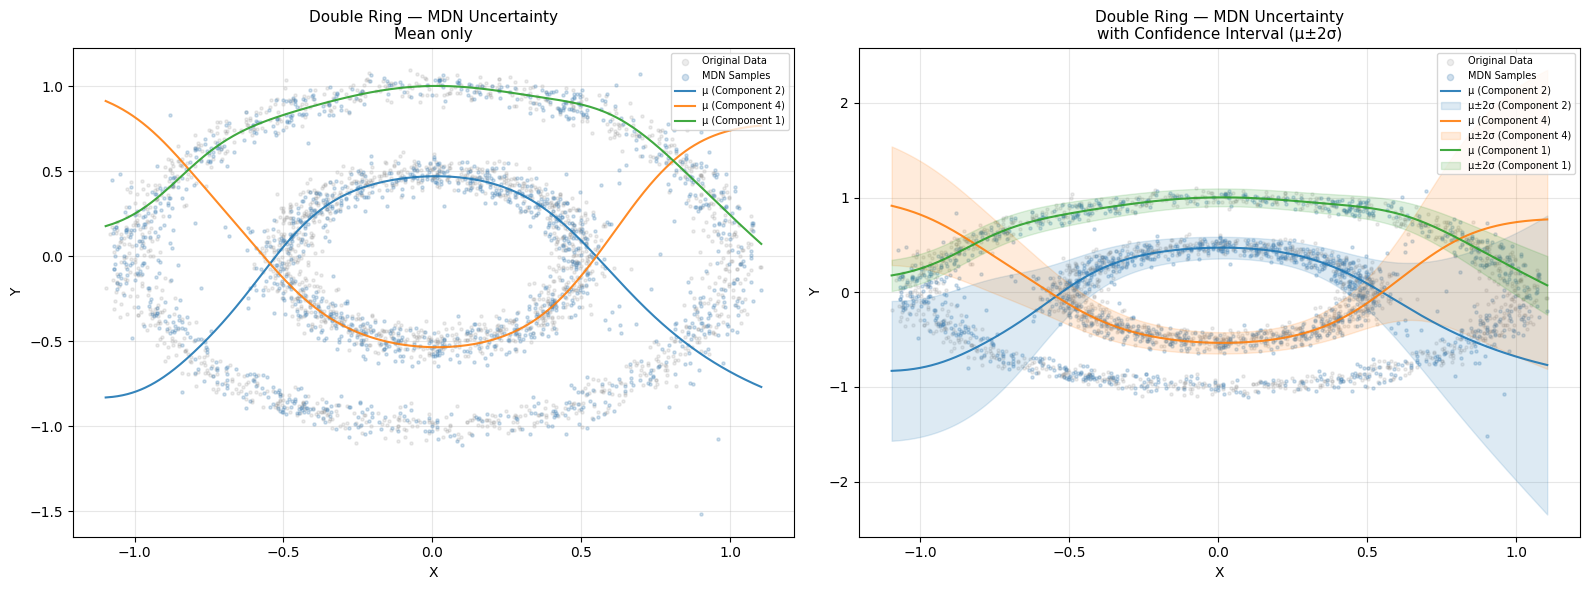

In [19]:
# ── 과제 3-1: Double Ring 불확실성 시각화 ──
plot_uncertainty(
    X_circle, y_circle, model_circle, K_circle,
    title='Double Ring — MDN Uncertainty',
    n_samples=1500, top_k=3
)

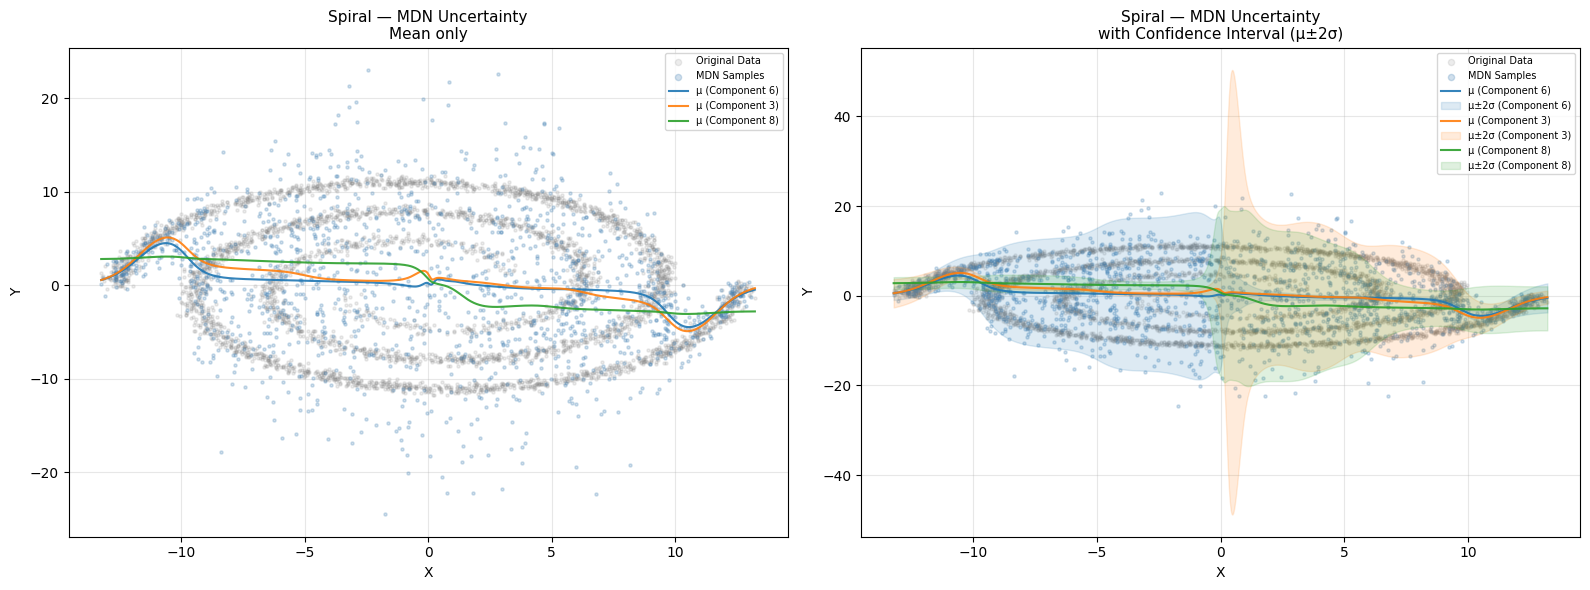

In [20]:
# ── 과제 3-2: Spiral 불확실성 시각화 ──
plot_uncertainty(
    X_spiral, y_spiral, model_spiral, K_spiral,
    title='Spiral — MDN Uncertainty',
    n_samples=1500, top_k=3
)

### 3. 예측 불확실성 시각화 결과

#### 시각화 구성 요소 해석

| 요소 | 의미 |
|------|------|
| 회색 점 (Original Data) | 실제 학습 데이터 분포 |
| 파란 점 (MDN Samples) | 모델이 생성한 샘플 |
| 실선 (μ per Component) | 각 Gaussian 컴포넌트의 평균 — 모드(mode) 위치 |
| 음영 (μ±2σ) | 95% 신뢰구간 — 넓을수록 불확실성 높음 |

#### Double Ring 불확실성 분석
- **Component 2 (파랑)**: 바깥쪽 원의 하단 호(y < 0 구간)를 담당, x=0 부근에서 σ가 커지며 음영 확대 → 두 원이 y 방향으로 겹치는 구간에서 불확실성 증가
- **Component 4 (주황)**: x > 0 구간의 상단 호를 담당, 원형 경계를 벗어나는 x 극단부에서 σ 급격히 증가
- **Component 1 (초록)**: 바깥쪽 원의 상단 호 담당, 전 구간에서 σ 비교적 안정적
- 세 컴포넌트의 μ가 서로 교차하는 x=±0.5 구간에서 음영이 겹치며 **모델이 어느 모드에 속하는지 가장 불확실한 구간**임을 명확히 표현

#### Spiral 불확실성 분석
- **세 컴포넌트 모두 μ가 y=0 부근에 집중**: 나선이 x 방향으로 퍼져있어 x 기준 정렬 시 y의 분포가 중앙으로 모이는 특성
- **x=0 부근에서 σ가 극단적으로 커짐** (음영이 y=±40 이상으로 확대): 나선의 두 팔이 중앙에서 교차하며 y 값이 넓게 분산 → **가장 높은 불확실성 구간**
- **x 극단부(|x| > 10)에서 σ 감소**: 나선의 끝부분은 하나의 팔만 존재하여 분포가 단순해짐
- Spiral의 NLL(3.1253)이 Double Ring(-0.0094)보다 높은 이유가 이 넓은 σ로 시각적으로 확인됨

#### 핵심 결론
- MDN은 단순 점 예측이 아니라 **예측의 신뢰도(σ)를 명시적으로 표현** — 불확실한 구간을 스스로 인식
- Double Ring처럼 구조가 규칙적일수록 σ가 작고 안정적, Spiral처럼 복잡할수록 σ가 크고 가변적
- μ±2σ 음영은 **추가 데이터가 필요한 구간 식별**, **예측 신뢰도 기반 의사결정** 등 실무에서 활용 가능